In [1]:
ROOT_DIR = "/home/albert/Baikal2025/"
import os
import sys
sys.path.append(ROOT_DIR)

import matplotlib.pyplot as plt
import numpy as np

from data_manager.root2df.main import RootFileReader
from data_manager.root2df.internal_root_paths import ExpRecoRootPaths

In [2]:
root_reco_dir = "/home/albert/Baikal2025/data_manager/data/mc_reco_root/nuatm_conv_files"
bad_parts = sorted([p for p in os.listdir(root_reco_dir) if 'cl1' in p])

In [3]:
name = bad_parts[2]
print(name)
path_to_exproot = f"{root_reco_dir}/{name}"
with RootFileReader(path_to_exproot, ExpRecoRootPaths) as rf:
    pulses_df = rf.read_pulses_as_df()[1:].to_pandas()

2020_cl1_run1002_scl_nu_MC_s19-21.root


In [4]:
pulses_df

,PulsesChID,PulsesAmpl,PulsesTime,PulsesTrueAmpl,SignalFlg,ev_id
0,3,1.087868,-1126.595337,1.087868,0,1
1,15,1.140498,-604.175415,1.140498,0,1
2,18,1.266118,2927.388184,1.266118,0,1
3,33,0.843175,-281.022583,0.843175,0,1
4,33,0.405631,1068.453735,0.405631,0,1
...,...,...,...,...,...,...
3552,281,0.967781,992.237366,0.967781,1,36
3553,285,0.550320,199.754196,0.550320,0,36
3554,286,0.138149,1209.248535,0.138149,0,36
3555,323,0.862488,-1432.799438,0.862488,0,36


Text(0.5, 1.0, 'Std of events times\nin 2020_cl1_run1002_scl_nu_MC_s19-21.root')

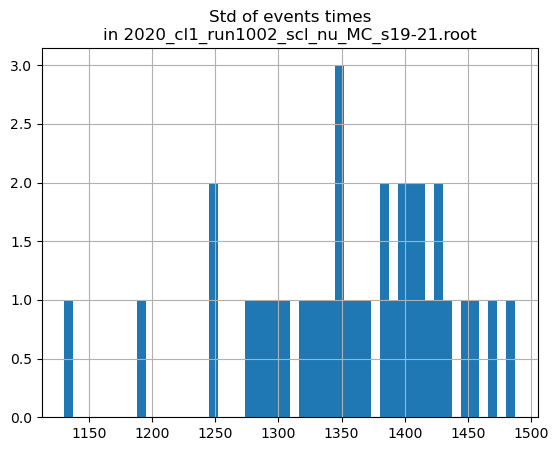

In [5]:
pulses_df.groupby('ev_id')['PulsesTime'].apply(np.std).hist(bins=50)
plt.title(f"Std of events times\nin {name}")